https://www.machinio.com/

In [3]:
from botasaurus.browser import browser, Driver
from botasaurus.request import request, Request
from botasaurus.soupify import soupify
from time import sleep
import pandas as pd

from itertools import chain

import re

import plotly.express as px
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [4]:
def per_page(data):

    title, links, manufacture, price, location, status, desc, stars, auction, data_id = [], [], [], [], [], [], [], [], [], []
    
    for i in data:
        #print(i)
        # scrape_luar(i)
        new_tab = None
        h4 = i.find("h4")
        
        try:
            auctioncek = i.find("div", {"class": "lead-wizard-modal-open-button-container"})['data-contactable']
        except:
            auctioncek = 'true'
            new_tab = True
    
        if auctioncek == 'true':
            if  new_tab:
                auction.append('Yes')
            else:
                auction.append('No')
                
            try: title.append(h4.get_text())
            except: title.append('-')
    
            try: links.append(h4.find("a", {"class": "c-card__title c-listing-card__title"})['href'])
            except: links.append('-')
    
            try: data_id.append(h4.find("a", {"class": "c-card__title c-listing-card__title"})['data-id'])
            except: data_id.append('-')
    
            try: manufacture.append(i.find("span", {"c-listing-card__spec-value"}).get_text())
            except: manufacture.append('-')
    
            try: price.append(i.find("div", {"c-listing-card__price"}).get_text())
            except: price.append('-')
    
            try: location.append(i.find("div", {"c-card__text-light c-listing-card__location"}).get_text())
            except: location.append('-')
    
            try: status.append(i.find("li", {"c-listing-card__spec-used"}).get_text())
            except: status.append('-')
    
            try: desc.append(i.find("p", {"c-card__text"}).get_text())
            except: desc.append('-')
    
            try: stars.append(i['data-star-count'])
            except: stars.append('-')
    
    a = {
            'title': title,
            'links': links,
            'manufacture': manufacture,
            'price': price,
            'location': location,
            'status': status,
            'desc': desc,
            'stars': stars,
            'auction': auction,
            'data_id': data_id,
        }
    return a

In [5]:
## Request type
@request(
    output=None,
)
def scrape_detail_req(request: Request, link):
    
    title, links, manufacture, price, location, status, desc, stars, auction, data_id = [], [], [], [], [], [], [], [], [], []
    
    response =  request.get("https://www.machinio.com/?location=&search=combilift")

    soup = soupify(response)

    total_pages = int(soup.find("div", {"id": "search-results"})['data-total-pages'])

    for i in range(1, total_pages+1, 1):
        response =  request.get("https://www.machinio.com/?page={}&search=combilift".format(i))
        soup = soupify(response)
        cok = soup.find("ul", {"class": "offer-listing__list"})
        
        jing = cok.find_all("li", {"class": "c-card c-card--link c-listing-card c-card--highlighted"})

        hasil = per_page(jing)
        
        title += hasil['title']
        links += hasil['links']
        manufacture  += hasil['manufacture']
        price += hasil['price']
        location += hasil['location']
        status += hasil['status']
        desc += hasil['desc']
        stars += hasil['stars']
        auction += hasil['auction']
        data_id += hasil['data_id']
    
    a = {
        'title': title,
        'links': links,
        'manufacture': manufacture,
        'price': price,
        'location': location,
        'status': status,
        'desc': desc,
        'stars': stars,
        'auction': auction,
        'data_id': data_id,
    }
    return pd.DataFrame.from_dict(a)

ea = scrape_detail_req()

Running


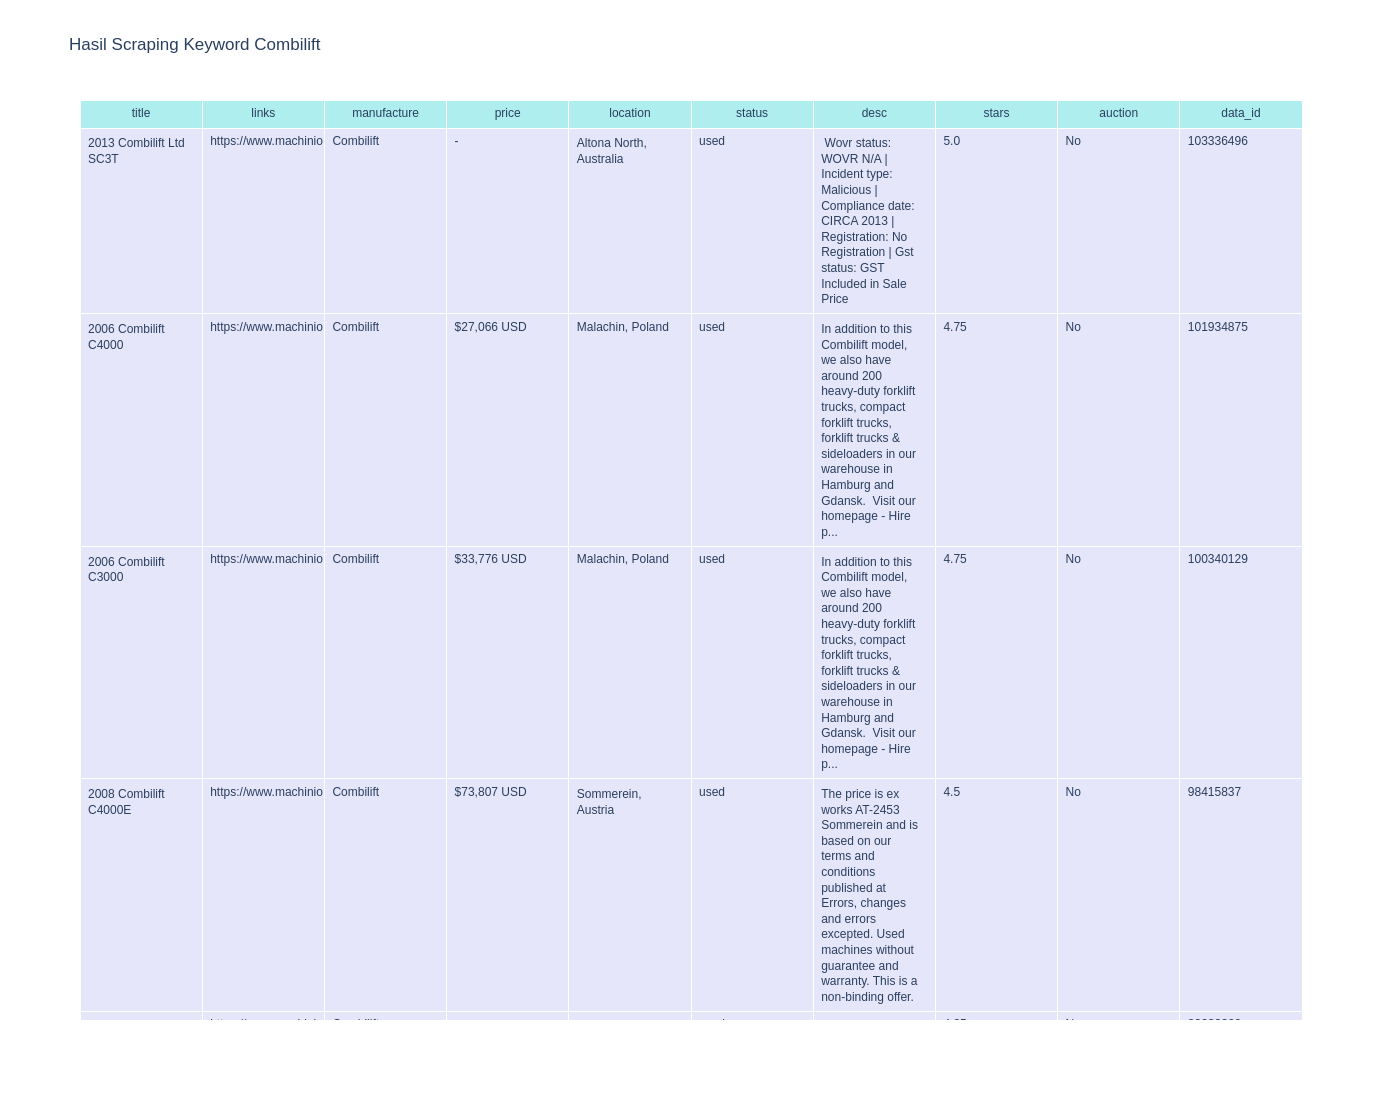

In [23]:
fig = go.Figure(
    data=[
        go.Table(
            header = dict(values=list(ea.columns),
                         fill_color='paleturquoise',
                         align='center',
                         ),
            cells = dict(values=[ea.head(5).title,
                                ea.head(5).links,
                                ea.head(5).manufacture,
                                ea.head(5).price,
                                ea.head(5).location,
                                ea.head(5).status,
                                ea.head(5).desc,
                                ea.head(5).stars,
                                ea.head(5).auction,
                                ea.head(5).data_id],
                        fill_color='lavender',
                        align='left')
        )
    ]
)

fig.update_layout(
                  title="Hasil Scraping Keyword Combilift", 
                  height=1100,
                 )
fig.show()

In [7]:
ea['links'] = ea['links'].apply(lambda x:'https://www.machinio.com' + x)

In [8]:
ea[ea['links'].str.contains('https://www.machinio.comhtt') == True] ## harus tambahin template request dari web dibawah

,title,links,manufacture,price,location,status,desc,stars,auction,data_id
7,2013 Combilift C4000,https://www.machinio.comhttps://www.bpiauction...,Combilift,-,"Normanton, United Kingdom",used,2013 Combilift C4000 Gas Side Loader Forklift\...,4.5,Yes,103227671
8,2020 Combilift SC3TA,https://www.machinio.comhttps://euroauctions.c...,Combilift,-,"Omagh, United Kingdom",used,"2020 Combilift SC3TA 71"" Telescopic Diesel Str...",3.75,Yes,102875347
19,2020 Combilift C12000WSL,https://www.machinio.comhttps://www.allsurplus...,Combilift,-,"Grand Junction, CO",used,2020 Combilift C12000WSL 12000 Lb Capacity Pne...,4.25,Yes,103320532
50,2020 Combilift SC3TA,https://www.machinio.comhttps://www.yoderandfr...,Combilift,-,"Hammond, TX",used,"[""2020 Combilift SC3TA 71\"" Telescopic Diesel ...",0,Yes,103102016
69,2012 Combi Lift C4000,https://www.machinio.comhttps://euroauctions.c...,Combilift,-,"Leeds, United Kingdom",used,"2012 Combi Lift C4000 Gas Forklift, 2 Stage Ma...",3.75,Yes,103260639
70,2019 Combi Lift C6000,https://www.machinio.comhttps://euroauctions.c...,Combilift,-,Marketplace,used,"2019 Combi Lift C6000 Side Loader Forklift, 3 ...",3.75,Yes,102875316


In [9]:
ea = ea[ea['links'].str.contains('https://www.machinio.comhtt') == False]

In [10]:
def get_detail(soup):
    desc = '-'
    try:
        desc = soup.find("div", {"id": "accordionDescription"}).get_text() ## description
    except: pass

        
    model = soup.find("div", {"id": "model-name"}).find("dd").get_text() ## model
    manufacture = soup.find("div", {"id": "manufacturer-name"}).find("dd").get_text() ## manufacturer

    price = "-"
    try:
        price = soup.find("div", {"class": "listing-primary-info__price--known"}).get_text() ## price
    except:
        try:
            price = soup.find("div", {"class": "listing-primary-info__price--unknown"}).get_text() ## price
        except:
            pass

    phone_number = "-"
    try:
        phone_number = soup.find("span", {"class": "seller-direct-contact-box-phone__number"}).get_text()
    except: pass

    capacity, lift_height, hours, engine_type, year, serial_number = "-","-","-","-","-","-",
    for i in soup.find_all("div", {"class": "spec-set__item"}):
        cek = i.find("dt").get_text()
        if re.search(r'\bcapacity\b', cek, re.I): ## capacity
            capacity = i.find("dd").get_text()
        if re.search(r'lifting height|lift height', cek, re.I): ## lift height
            lift_height = i.find("dd").get_text()
        if re.search(r'\bhours\b|\bhrs\b', cek, re.I): ## hours
            hours = i.find("dd").get_text()
        if re.search(r'\bengine\b|\bpower\b|\bfuel\b|\bpropulsion\b|\bmotor\b', cek, re.I): ## engine type
            engine_type = i.find("dd").get_text()
        if re.search(r'\byear\b', cek, re.I): ## year
            year = i.find("dd").get_text()
        if re.search(r'\bnumber\b', cek, re.I): ## serial number
            serial_number = i.find("dd").get_text()

    hasil = {
        'desc': desc,
        'model': model,
        'manufacture': manufacture,
        'price': price,
        'phone_number': phone_number,
        'capacity': capacity,
        'lift_height': lift_height,
        'hours': hours,
        'engine_type': engine_type,
        'year': year,
        'serial_number': serial_number,
    }

    return hasil

In [11]:
## Request type
@request(
    output=None,
    data = ea['links'].to_list,
)
def scrape_detail1_req(request: Request, link):
    data_list = []
    
    #title, links, manufacture, price, location, status, desc, stars, auction, data_id = [], [], [], [], [], [], [], [], [], []
    
    response =  request.get(link)

    soup = soupify(response)

    data_list.append(get_detail(soup))
    # ea = soup.find("div", {"id": "accordionDescription"}).get_text()
    # print(ea)
    return data_list



In [12]:
hasil_detail = scrape_detail1_req()

In [13]:
hasil_detail[3]

[{'desc': 'The price is ex works AT-2453 Sommerein and is based on our terms and conditions published at Errors, changes and errors excepted. Used machines without guarantee and warranty. This is a non-binding offer.',
  'model': 'C4000',
  'manufacture': 'Combilift',
  'price': '$73,807 USD',
  'phone_number': '-',
  'capacity': '4000 kg',
  'lift_height': '7500 mm',
  'hours': '1000',
  'engine_type': '-',
  'year': '2008',
  'serial_number': 'GM126324'}]

In [14]:
hasil_detail = list(chain.from_iterable(hasil_detail))
df = pd.DataFrame.from_dict(hasil_detail)

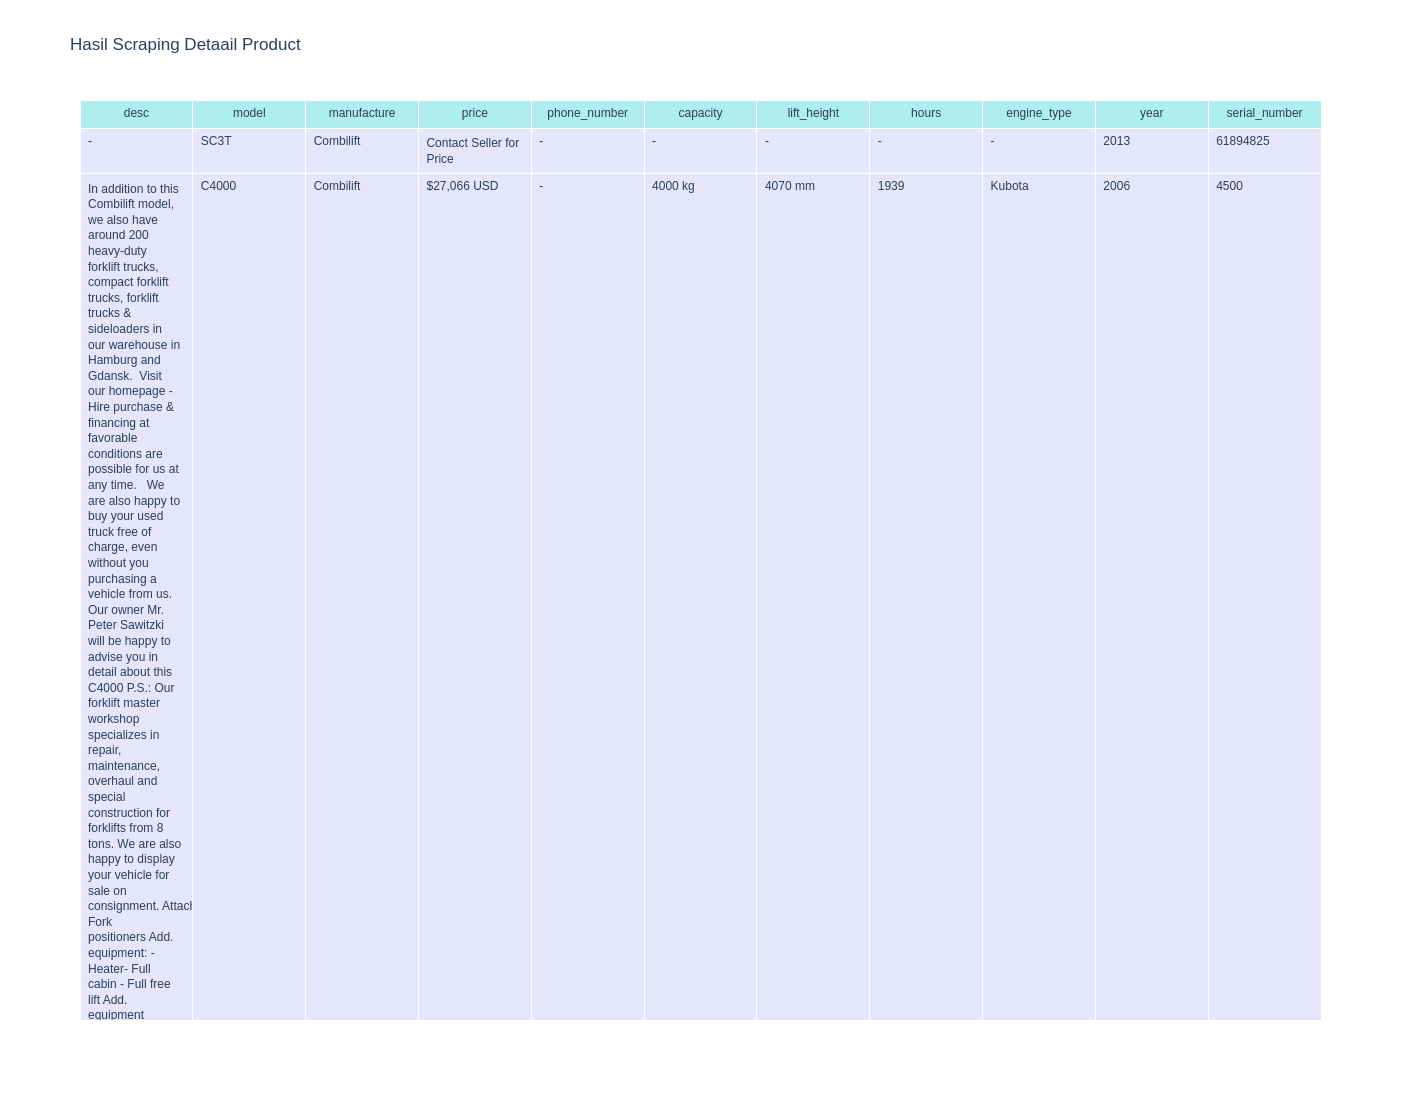

In [26]:
fig = go.Figure(
    data=[
        go.Table(
            header = dict(values=list(df.columns),
                         fill_color='paleturquoise',
                         align='center',
                         ),
            cells = dict(values=[df.head(3).desc,
                                df.head(3).model,
                                df.head(3).manufacture,
                                df.head(3).price,
                                df.head(3).phone_number,
                                df.head(3).capacity,
                                df.head(3).lift_height,
                                df.head(3).hours,
                                df.head(3).engine_type,
                                df.head(3).year,
                                df.head(3).serial_number],
                        fill_color='lavender',
                        align='left')
        )
    ]
)

fig.update_layout(
                  title="Hasil Scraping Detaail Product", 
                  height=1100,
                 )
fig.show()

In [15]:
df.head(3)

,desc,model,manufacture,price,phone_number,capacity,lift_height,hours,engine_type,year,serial_number
0,-,SC3T,Combilift,Contact Seller for Price,-,-,-,-,-,2013,61894825
1,"In addition to this Combilift model, we also h...",C4000,Combilift,"$27,066 USD",-,4000 kg,4070 mm,1939,Kubota,2006,4500
2,"In addition to this Combilift model, we also h...",C3000,Combilift,"$33,776 USD",-,3000 kg,4550 mm,7009,VW,2006,4422


In [16]:
ea.head(3)

,title,links,manufacture,price,location,status,desc,stars,auction,data_id
0,2013 Combilift Ltd SC3T,https://www.machinio.com/listings/103336496-20...,Combilift,-,"Altona North, Australia",used,Wovr status: WOVR N/A | Incident type: Malici...,5.0,No,103336496
1,2006 Combilift C4000,https://www.machinio.com/listings/101934875-20...,Combilift,"$27,066 USD","Malachin, Poland",used,"In addition to this Combilift model, we also h...",4.75,No,101934875
2,2006 Combilift C3000,https://www.machinio.com/listings/100340129-20...,Combilift,"$33,776 USD","Malachin, Poland",used,"In addition to this Combilift model, we also h...",4.75,No,100340129


In [17]:
df.shape

(142, 11)

In [18]:
ea.shape

(142, 10)

In [19]:
df_comb = df.combine_first(ea)

In [22]:
df_comb.columns

Index(['auction', 'capacity', 'data_id', 'desc', 'engine_type', 'hours',
       'lift_height', 'links', 'location', 'manufacture', 'model',
       'phone_number', 'price', 'serial_number', 'stars', 'status', 'title',
       'year'],
      dtype='object')

In [21]:
df_comb

,auction,capacity,data_id,desc,engine_type,hours,lift_height,links,location,manufacture,model,phone_number,price,serial_number,stars,status,title,year
0,No,-,103336496,-,-,-,-,https://www.machinio.com/listings/103336496-20...,"Altona North, Australia",Combilift,SC3T,-,Contact Seller for Price,61894825,5.0,used,2013 Combilift Ltd SC3T,2013
1,No,4000 kg,101934875,"In addition to this Combilift model, we also h...",Kubota,1939,4070 mm,https://www.machinio.com/listings/101934875-20...,"Malachin, Poland",Combilift,C4000,-,"$27,066 USD",4500,4.75,used,2006 Combilift C4000,2006
2,No,3000 kg,100340129,"In addition to this Combilift model, we also h...",VW,7009,4550 mm,https://www.machinio.com/listings/100340129-20...,"Malachin, Poland",Combilift,C3000,-,"$33,776 USD",4422,4.75,used,2006 Combilift C3000,2006
3,No,4000 kg,98415837,The price is ex works AT-2453 Sommerein and is...,-,1000,7500 mm,https://www.machinio.com/listings/98415837-200...,"Sommerein, Austria",Combilift,C4000,-,"$73,807 USD",GM126324,4.5,used,2008 Combilift C4000E,2008
4,No,5500,80023360,Fork positioners\n3rd valve\n4th valve - Full ...,13,"64,8",6.120,https://www.machinio.com/listings/80023360-202...,"Crailsheim, Germany",Combilift,SC,-,Contact Seller for Price,-,4.25,used,2022 Combilift 05EPZS0700SC,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,No,NaN,101411834,Hours: 2560 | Fuel type: Propane,NaN,NaN,NaN,https://www.machinio.com/listings/101411834-20...,"Bristol, PA",Combilift,NaN,NaN,"$59,875 USD",NaN,4.25,used,2018 Combi Lift C6000 145617,NaN
144,No,NaN,101169605,Hours: 345 | Fuel type: Propane,NaN,NaN,NaN,https://www.machinio.com/listings/101169605-20...,"Bristol, PA",Combilift,NaN,NaN,"$59,875 USD",NaN,4.25,used,2017 Combi Lift C6000 145488,NaN
145,No,NaN,100708535,Hours: 900 | Fuel type: Propane | Tires: Cush...,NaN,NaN,NaN,https://www.machinio.com/listings/100708535-20...,"Bristol, PA",Combilift,NaN,NaN,"$49,500 USD",NaN,4.25,used,2017 Combi Lift CB6000 145205,NaN
146,No,NaN,100552037,Equipped With\nGeneral Specifications:\nManufa...,NaN,NaN,NaN,https://www.machinio.com/listings/100552037-20...,"Waukesha, WI",Combilift,NaN,NaN,-,NaN,4.75,used,2008 COMBILIFT CL60100LA24,NaN


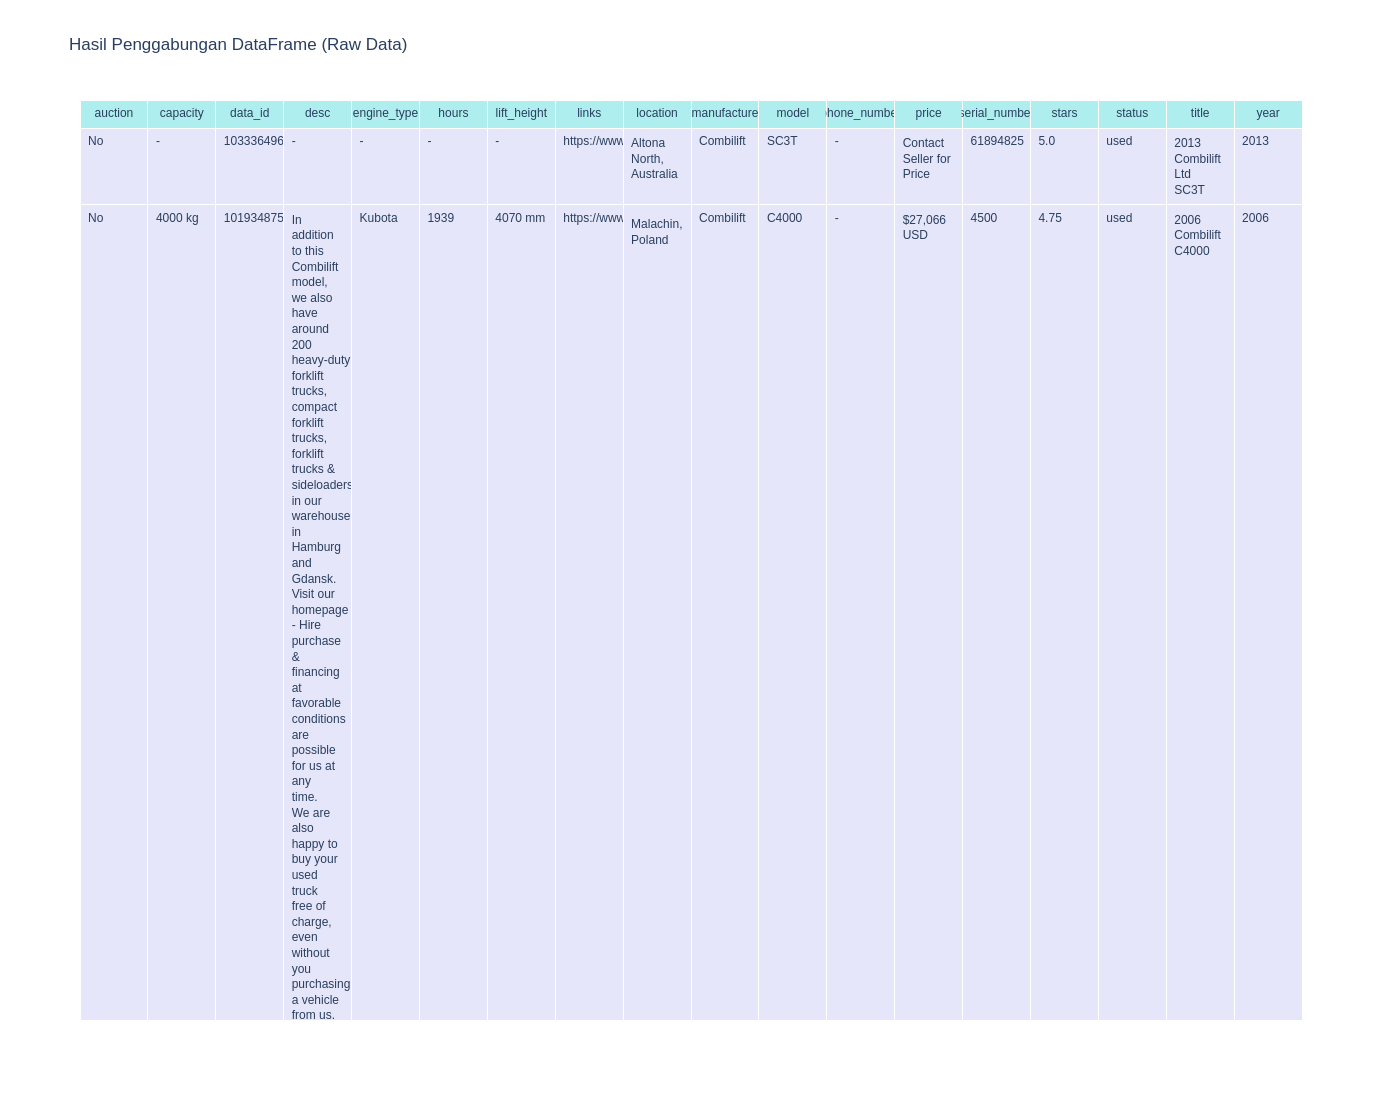

In [30]:
fig = go.Figure(
    data=[
        go.Table(
            header = dict(values=list(df_comb.columns),
                         fill_color='paleturquoise',
                         align='center',
                         ),
            cells = dict(values=[df_comb.head(3).auction,
                                df_comb.head(3).capacity,
                                df_comb.head(3).data_id,
                                df_comb.head(3).desc,
                                df_comb.head(3).engine_type,
                                df_comb.head(3).hours,
                                df_comb.head(3).lift_height,
                                df_comb.head(3).links,
                                df_comb.head(3).location,
                                df_comb.head(3).manufacture,
                                df_comb.head(3).model,
                                df_comb.head(3).phone_number,
                                df_comb.head(3).price,
                                df_comb.head(3).serial_number,
                                df_comb.head(3).stars,
                                df_comb.head(3).status,
                                df_comb.head(3).title,
                                df_comb.head(3).year,],
                        fill_color='lavender',
                        align='left')
        )
    ]
)

fig.update_layout(
                  title="Hasil Penggabungan DataFrame (Raw Data)", 
                  height=1100,
                 )
fig.show()